# Exploratory Data Analysis for LandCover.ai v1

In [1]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec

In [2]:
image_path = "../data/raw/landcover.ai.v1/images/M-33-7-A-d-3-2.tif"
mask_path = "../data/raw/landcover.ai.v1/masks/M-33-7-A-d-3-2.tif" 

In [3]:
# Read the RGB image
with rasterio.open(image_path) as src:
    image = src.read([1, 2, 3]).transpose(1, 2, 0)  # (C,H,W) -> (H, W, C)

# Read the mask (single channel)
with rasterio.open(mask_path) as src:
    mask = src.read(1)

In [4]:
# Sınıf sırası: 0,1,2,3,4 
class_labels = [
    "Etiketlenmemiş",
    "Bina",
    "Ağaçlık Alan",
    "Su",
    "Yol"
]

class_colors = [
    "yellow",  # 0
    "gray",    # 1
    "green",   # 2
    "blue",    # 3
    "black"    # 4
]

legend_patches = [
    mpatches.Patch(color="gray",   label="Bina"),
    mpatches.Patch(color="green",  label="Ağaçlık Alan"),
    mpatches.Patch(color="blue",   label="Su"),
    mpatches.Patch(color="black",  label="Yol"),
    mpatches.Patch(color="yellow", label="Etiketlenmemiş")
]

# IMAGE - MASK

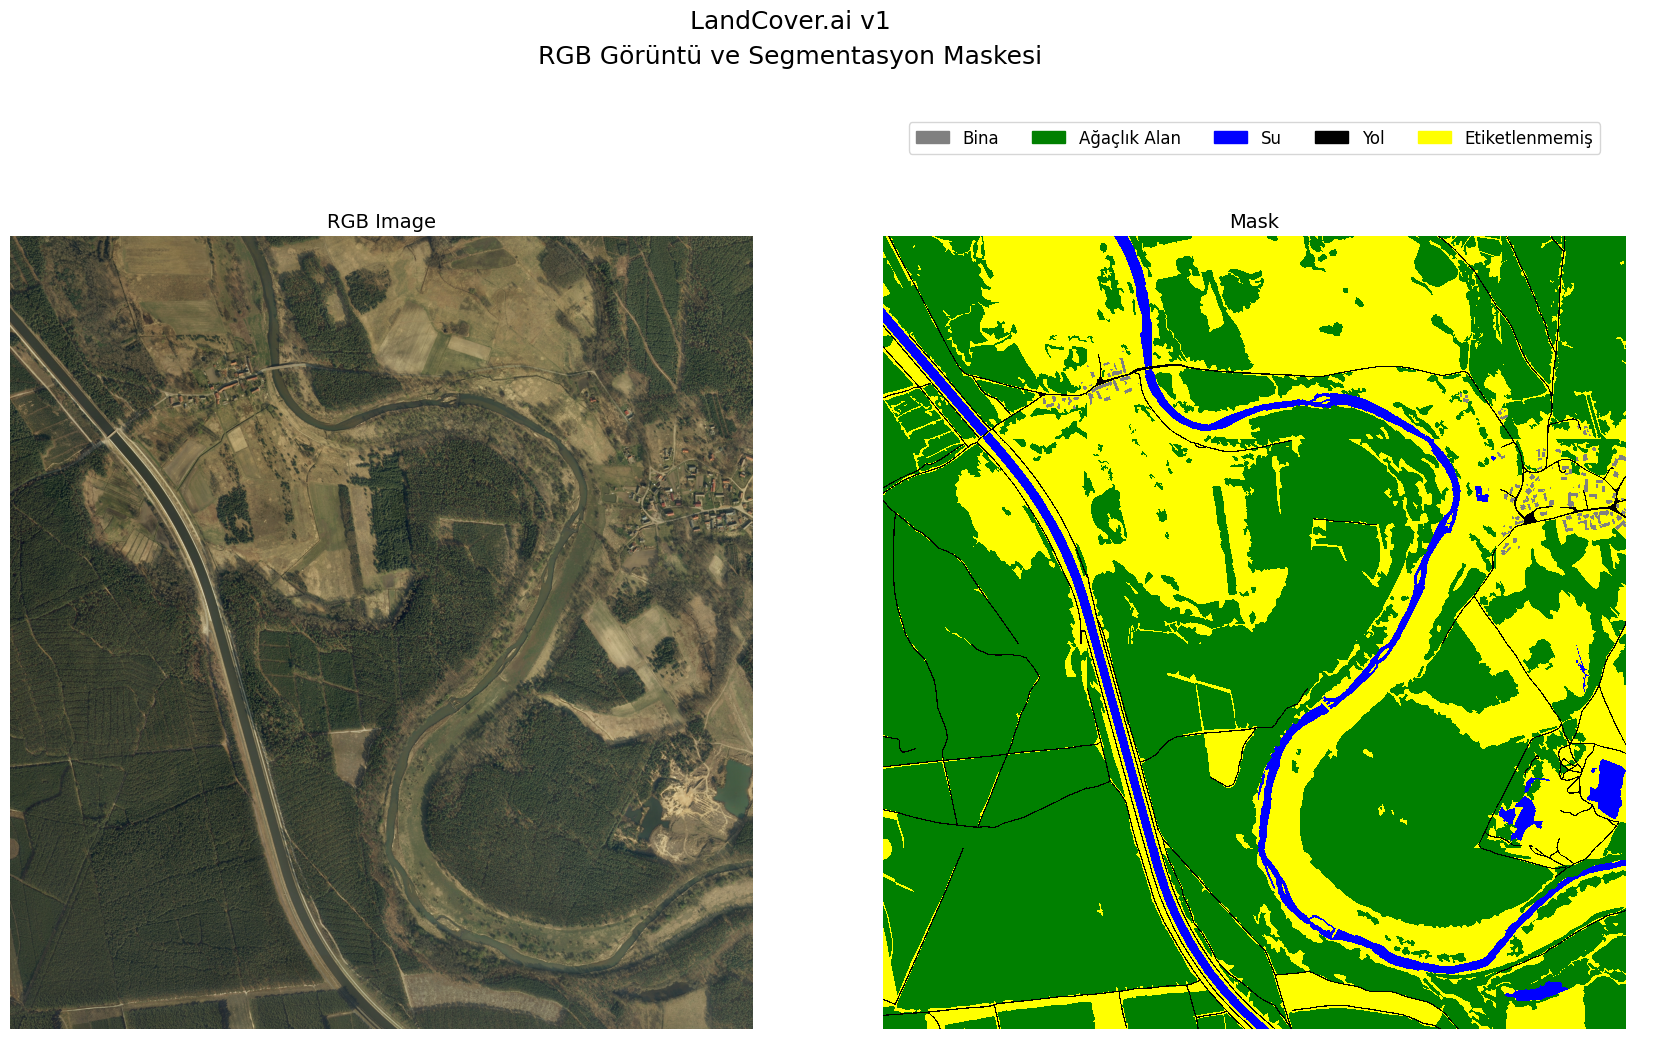

In [5]:
cmap = ListedColormap(class_colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(22, 12))
gs = GridSpec(
    2, 2,
    height_ratios=[1, 12],  
    hspace=0.15,
    wspace=0.05
)

fig.suptitle(
    "LandCover.ai v1\nRGB Görüntü ve Segmentasyon Maskesi",
    fontsize=18,
    y=0.96,
    linespacing=1.6
)

# Legend (mask üstü)
ax_legend = fig.add_subplot(gs[0, 1]) 
ax_legend.axis("off")

ax_legend.legend(
    handles=legend_patches,
    loc="center",
    ncol=len(legend_patches),
    frameon=True,
    fontsize=12
)

# RGB IMAGE 
ax1 = fig.add_subplot(gs[1, 0])
ax1.imshow(image)
ax1.set_title("RGB Image", fontsize=14)
ax1.axis("off")

# MASK
ax2 = fig.add_subplot(gs[1, 1])
ax2.imshow(mask, cmap=cmap, norm=norm, interpolation="nearest")
ax2.set_title("Mask", fontsize=14)
ax2.axis("off")

#save_path = "../figures/EDA/v1_EDA_image-mask.png"
#plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()


In [6]:
# Mask flatten
pixels = mask.flatten()

class_names = {
    0: "Etiketlenmemiş",
    1: "Bina",
    2: "Ağaçlık Alan",
    3: "Su",
    4: "Yol"
}

# Piksel sayımı
unique, counts = np.unique(pixels, return_counts=True)

df = pd.DataFrame({
    "Class ID": unique,
    "Sınıf": [class_names[i] for i in unique],
    "Piksel Sayısı": counts
})

# Oran (%)
total_pixels = counts.sum()
df["Oran (%)"] = 100 * df["Piksel Sayısı"] / total_pixels

df

,Class ID,Sınıf,Piksel Sayısı,Oran (%)
0,0,Etiketlenmemiş,31180689,35.316250
1,1,Bina,324909,0.368002
2,2,Ağaçlık Alan,51703029,58.560512
3,3,Su,3286107,3.721950
4,4,Yol,1795186,2.033285


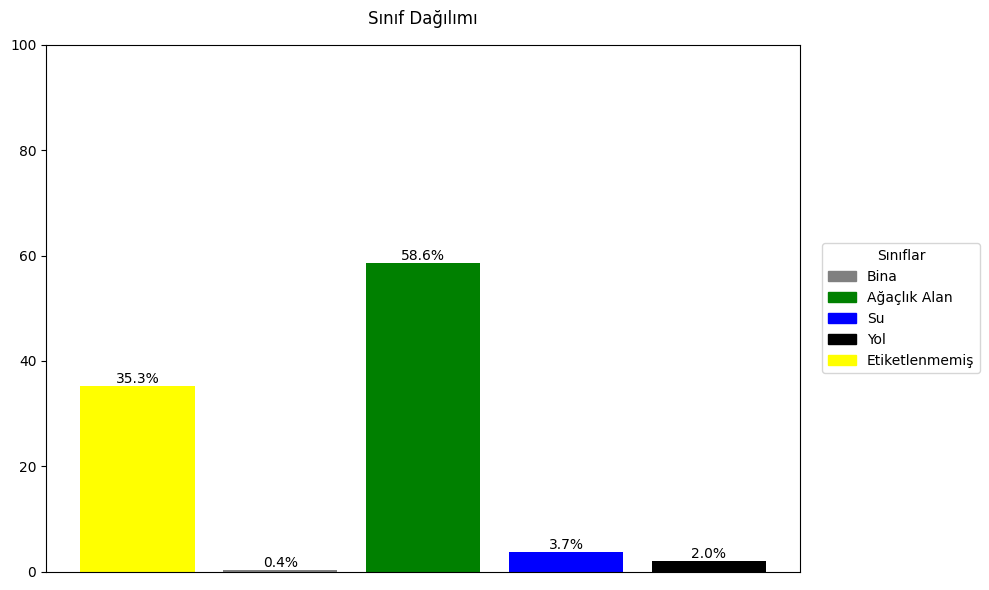

In [8]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    class_labels,
    df.sort_values("Class ID")["Oran (%)"],
    color=class_colors
)

plt.title("Sınıf Dağılımı", pad=15)
plt.xticks([])
plt.ylim(0, 100)

# Yüzde etiketleri
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

# Legend
plt.legend(
    handles=legend_patches,
    title="Sınıflar",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout()

#save_path = "../figures/EDA/v1_classes_bar_chart.png"
#plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

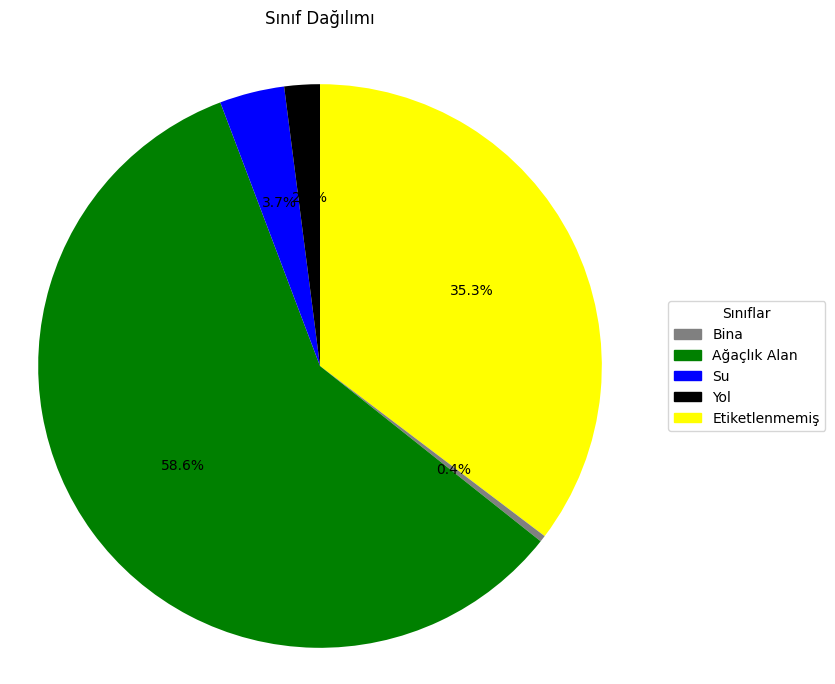

In [9]:
plt.figure(figsize=(8, 8))

plt.pie(
    df.sort_values("Class ID")["Oran (%)"],
    colors=class_colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

plt.title("Sınıf Dağılımı", pad=25)

# Legend
plt.legend(
    handles=legend_patches,
    title="Sınıflar",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=True
)

plt.axis("equal")

#save_path = "../figures/EDA/v1_classes_pie_chart.png"
#plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


### Mask Overlay on RGB Image

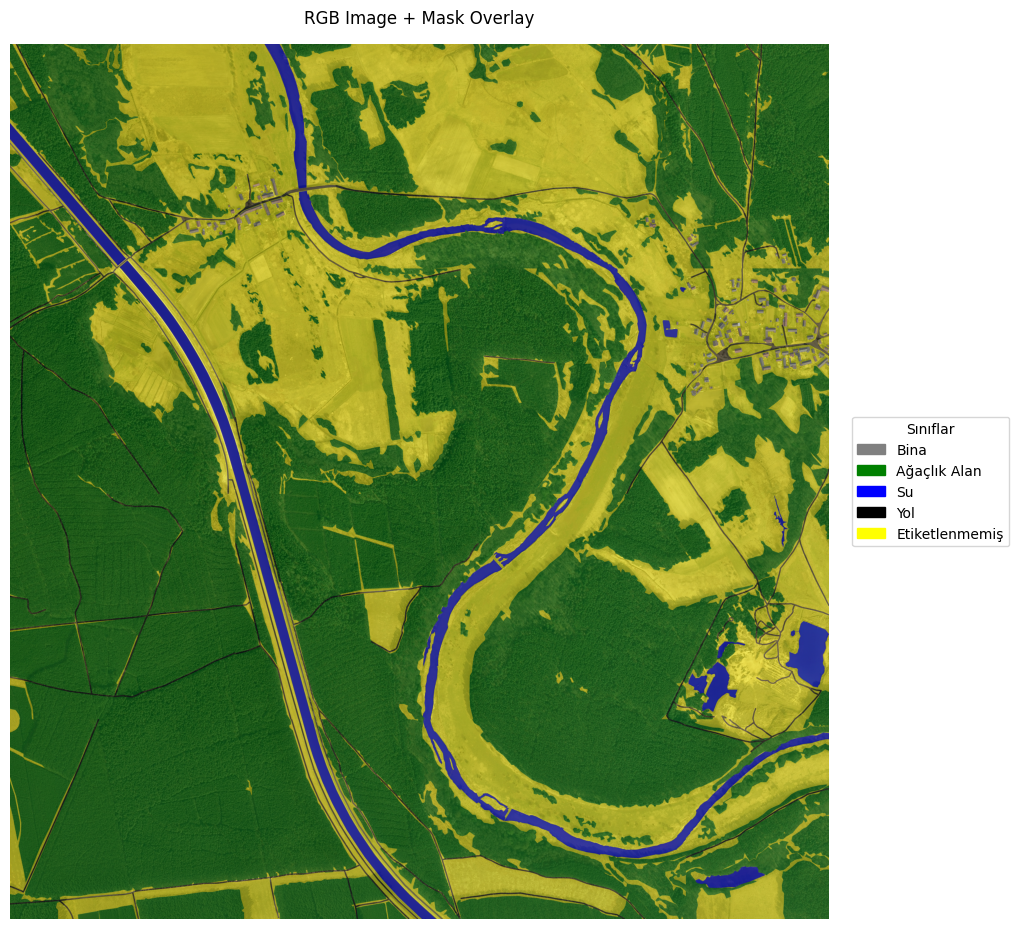

In [10]:

plt.figure(figsize=(10, 10))

# RGB Image
plt.imshow(image)
plt.axis("off")

# Mask overlay (yarı saydam)
plt.imshow(
    mask,
    cmap=cmap,
    norm=norm,
    alpha=0.45  # overlay şeffaflığı
)

plt.title("RGB Image + Mask Overlay", pad=15)

# Legend (sağa)
plt.legend(
    handles=legend_patches,
    title="Sınıflar",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout()

#save_path = "../figures/EDA/v1_EDA_overlay.png"
#plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()
